(10, 8183, 6) (10, 8183)
(1629, 6)
(1115, 6) (514, 6)


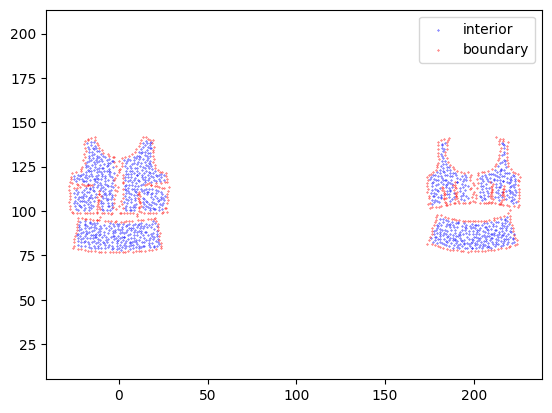

In [1]:
import numpy as np 
import os, glob 
import tqdm
import igl 
import matplotlib.pyplot as plt
file = "/orion/u/w4756677/garment/InteractGarment/src/outputs/v2/2025-10-13/15-46-27/samples_0160000/img_data.npz"
data = np.load(file)
preds = data["preds"]
mask = data["mask"]
print(preds.shape, mask.shape)
idx = 3
pred = preds[idx]
mask = mask[idx]
pred = pred[mask]
pred[:, 0] = pred[:, 0] * (100 + 100) - 100
pred[:, 1] = pred[:, 1] * (160 + 20) - 20

print(pred.shape)
interior_flag = pred[:, -1] < 0.5
interior_verts = pred[interior_flag]
boundary_verts = pred[~interior_flag]
print(interior_verts.shape, boundary_verts.shape)
plt.scatter(interior_verts[:, 0], interior_verts[:, 1], c="b", s=0.1, label="interior")
plt.scatter(boundary_verts[:, 0], boundary_verts[:, 1], c="r", s=0.1, label="boundary")
plt.axis("equal")
plt.legend()
plt.show()


5.864372717262857
(514, 1)


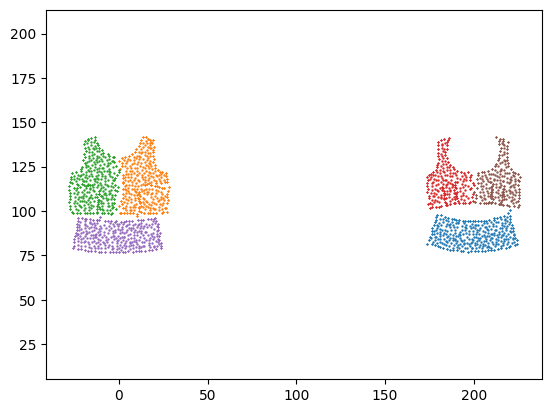

In [2]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from scipy.spatial import cKDTree
nbh = NearestNeighbors(n_neighbors=2).fit(interior_verts)
d1 = nbh.kneighbors(interior_verts)[0][:,1]
eps = 3 * np.median(d1)  # tweak
print(eps)
interior_labels = DBSCAN(eps=eps, min_samples=5).fit_predict(interior_verts)
n_classes = len(set(interior_labels) - {-1})
tree = cKDTree(interior_verts)
nbrs = tree.query_ball_tree(tree, r=eps)
boundary_tree = cKDTree(boundary_verts)
nbrs_AB = nbh.kneighbors(boundary_verts, 1, return_distance=False)
print(nbrs_AB.shape)
boundary_labels = interior_labels[nbrs_AB].flatten()
verts = np.concatenate([interior_verts, boundary_verts], axis=0)
labels = np.concatenate([interior_labels, boundary_labels], axis=0)
for i in range(n_classes):
    plt.scatter(interior_verts[interior_labels == i, 0], interior_verts[interior_labels == i, 1], c=f"C{i}",marker="o", s=0.5)
    plt.scatter(boundary_verts[boundary_labels == i, 0], boundary_verts[boundary_labels == i, 1], c=f"C{i}",marker="x", s=0.5)
plt.axis("equal")
plt.show()


In [3]:

def reorient_to_y(points):
    """
    points: (N,2) array of 2D points
    returns: rotated_points (N,2), rotation_matrix (2,2), angle_radians
    """
    P = np.asarray(points, dtype=float)
    # 1) center at centroid
    c = P.mean(axis=0)
    X = P - c

    # 2) principal direction via covariance eigendecomp (PCA)
    C = np.cov(X, rowvar=False)               # 2x2
    w, V = np.linalg.eigh(C)                  # symmetric -> sorted eigenvalues not guaranteed
    v = V[:, np.argmax(w)]                    # eigenvector of largest eigenvalue (major axis)

    # 3) rotation angle that maps v -> +y axis
    # For R(φ) = [[cosφ, -sinφ], [sinφ, cosφ]], choose φ so that R(φ) @ v = (0, ||v||)
    phi = np.arctan2(v[0], v[1])              # note the (vx, vy) order here

    # ensure it points toward +y (optional): flip 180° if pointing downward
    if (np.sin(phi)*v[0] + np.cos(phi)*v[1]) < 0:
        phi += np.pi

    cphi, sphi = np.cos(phi), np.sin(phi)
    R = np.array([[cphi, -sphi],
                  [sphi,  cphi]])

    # 4) rotate points; keep them centered (add c back if you want original location)
    X_rot = X @ R.T
    return X_rot + c, R, phi

(599, 3)
(598, 3)
(586, 3)
(401, 3)
(581, 3)
(393, 3)


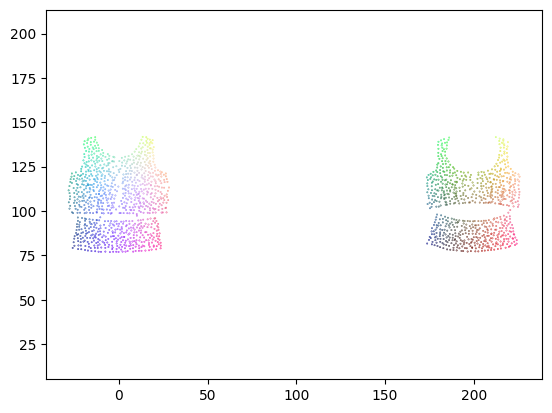

(1591, 6) (1591, 3)


In [4]:
# import Delaunay
from scipy.spatial import Delaunay
import trimesh
all_verts = []
all_simplices = []
offset = 0
for i in range(n_classes):
    verts = np.concatenate([interior_verts[interior_labels == i], boundary_verts[boundary_labels == i]], axis=0)
    all_verts.append(verts)
    inside_flag = verts[:, -1] < 0.5
    tri = Delaunay(verts[:, :2])
    print(tri.simplices.shape)
    new_simplices = []
    for k in range(tri.simplices.shape[0]):
        simplex = tri.simplices[k]
        simplex_flag = inside_flag[simplex]
        if simplex_flag.any():
            new_simplices.append(simplex)
    all_simplices.append(np.array(new_simplices) + offset)
    offset += len(verts)
all_verts = np.concatenate(all_verts, axis=0)
all_simplices = np.concatenate(all_simplices, axis=0)
vert_color = all_verts[:, 2:5]
vert_color = (vert_color - vert_color.min(0)) / (vert_color.max(0) - vert_color.min(0))
# plt.triplot(all_verts[:, 0], all_verts[:, 1], all_simplices)
plt.scatter(all_verts[:, 0], all_verts[:, 1], c=vert_color, s=0.1)
# plt.scatter(verts[inside_flag, 0], verts[inside_flag, 1], color='red')
# plt.scatter(verts[~inside_flag, 0], verts[~inside_flag, 1], color='blue')
plt.axis("equal")
plt.show()
plt.close()

mesh = trimesh.Trimesh(vertices=all_verts[:, 2:5], faces=all_simplices)
mesh.export("mesh.obj")
mesh_verts = mesh.vertices
new_all_verts = np.zeros((mesh_verts.shape[0], all_verts.shape[1]))
for i, vert in enumerate(mesh_verts):
    diff = vert - all_verts[:, 2:5]
    dist = np.linalg.norm(diff, axis=-1)
    min_idx = np.argmin(dist)
    new_all_verts[i] = all_verts[min_idx]
    
print(new_all_verts.shape, mesh_verts.shape)


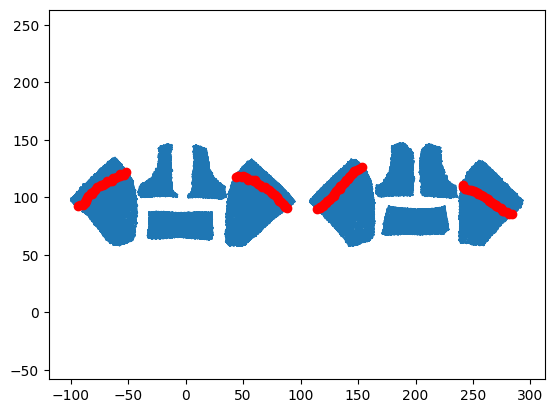

set()
set()
set()
set()
set()
set()
set()
set()


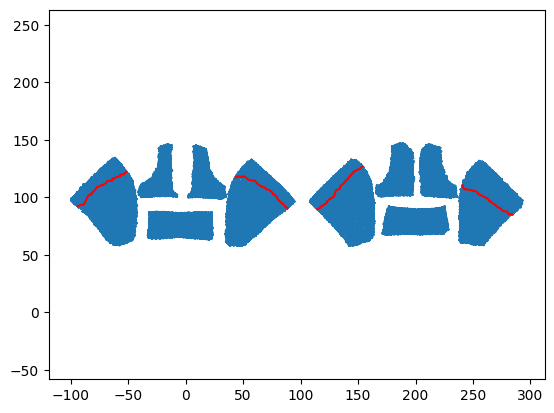

In [ ]:
lines = [
    [4299, 4350, 4360, 4381, 4433, 4449, 4494, 4501, 4545, 4579, 4629, 4656, 4669, 4696, 4738, 4766, 4806, 4820, 4846, 4860, 4871, 4880, 4928, 4943, 4972, 4996, 5009, 5075, 5103],
    [1514, 1536, 1565, 1598, 1676, 1711, 1830, 1871, 1897, 1899, 1930, 1968, 1994, 2027, 2031, 2043, 2053, 2069, 2071, 2107, 2110, 2111, 2121, 2127, 2137, 2187, 2208, 2247, 2283],
    [2590, 2608, 2637, 2688, 2734, 2787, 2788, 2800, 2872, 2935, 2974, 2997, 3001, 3010, 3013, 3051, 3125, 3127, 3146, 3164, 3183, 3188, 3195, 3202, 3203, 3204, 3260, 3367, 3379],
    [3480, 3487, 3498, 3508, 3513, 3547, 3554, 3597, 3602, 3675, 3693, 3741, 3766, 3815, 3820, 3848, 3867, 3894, 3896, 3930, 3954, 3964, 3970, 3979, 4026, 4059, 4080, 4133, 4151, 4155, 4203, 4257]
]
plt.triplot(new_all_verts[:, 0], new_all_verts[:, 1], mesh.faces)
for line in lines:
    plt.scatter(new_all_verts[line][:,0], new_all_verts[line][:,1], color='red')
plt.axis("equal")
plt.show()
plt.close()

# get all edges in the mesh 
edges = []
for i in range(mesh.faces.shape[0]):
    for j in range(3):
        edges.append([mesh.faces[i, j], mesh.faces[i, (j+1)%3]])
edges = np.array(edges)
# reorder the vertices by connectivity
new_lines = []
for line in lines:
    start_idx = line[0]
    current_idx = start_idx
    new_line = [current_idx]
    for i in range(len(line)):
        nbhd_edges = edges[edges[:, 0] == current_idx]
        nbhd_edges = np.concatenate([nbhd_edges, edges[edges[:, 1] == current_idx]], axis=0)
        for edge in nbhd_edges:
            if edge[1] == current_idx and edge[0] in line and edge[0] not in new_line:
                current_idx = edge[0].item()
                new_line.append(current_idx)
                break
            elif edge[0] == current_idx and edge[1] in line and edge[1] not in new_line:
                current_idx = edge[1].item()
                new_line.append(current_idx)
                break
    remaining_line = set(line).difference(set(new_line))
    current_idx = start_idx 
    for i in range(len(remaining_line)):
        nbhd_edges = edges[edges[:, 0] == current_idx]
        nbhd_edges = np.concatenate([nbhd_edges, edges[edges[:, 1] == current_idx]], axis=0)
        for edge in nbhd_edges:
            if edge[1] == current_idx and edge[0] in remaining_line and edge[0] not in new_line:
                current_idx = edge[0].item()
                new_line.insert(0, current_idx)
                break
            elif edge[0] == current_idx and edge[1] in remaining_line and edge[1] not in new_line:
                current_idx = edge[1].item()
                new_line.insert(0, current_idx)
                break
    new_lines.append(new_line)

plt.triplot(new_all_verts[:, 0], new_all_verts[:, 1], mesh.faces)
for i, line in enumerate(new_lines):
    plt.plot(new_all_verts[line][:,0], new_all_verts[line][:,1], color='red')
    # plt.scatter(new_all_verts[line][:,0], new_all_verts[line][:,1], color='red')
plt.axis("equal")
plt.show()
plt.close()

(9392,) 10 (9392, 3)


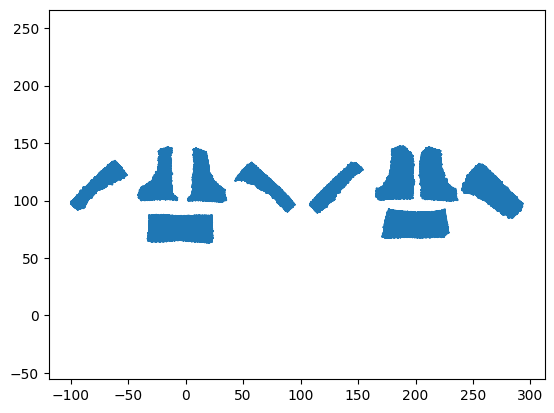

In [32]:
import shapely 
import igl 
n_components, components_ids = igl.facet_components(mesh.faces)
print(components_ids.shape, n_components, mesh.faces.shape)

new_verts = []
new_faces = []
old2new = {}
for i in range(n_components):
    panel_faces = mesh.faces[components_ids == i]
    keep = False
    for line in new_lines:
        if set(line).issubset(set(panel_faces.flatten())):
            keep = True
            break
    if not keep:
        for face in panel_faces:
            new_face = []
            for v in face:
                if v not in old2new:
                    old2new[v] = len(new_verts)
                    new_verts.append(new_all_verts[v])
                new_v = old2new[v]
                new_face.append(new_v)
            new_faces.append(new_face)
        continue
    boundary_ids = igl.boundary_loop(panel_faces)
    boundary_verts = new_all_verts[boundary_ids]
    polygon = shapely.Polygon(boundary_verts[:, :2])
    linestring = shapely.LineString(new_all_verts[line][:, :2])
    pieces = shapely.ops.split(polygon, linestring)
    p1 = pieces.geoms[0]
    p2 = pieces.geoms[1]
    p_keep = p1 if p1.area < p2.area else p2
    for face in panel_faces:
        center = np.mean(new_all_verts[face][:, :2], axis=0)
        if p_keep.contains(shapely.Point(center)):
            new_face = []
            for v in face:
                if v not in old2new:
                    old2new[v] = len(new_verts)
                    new_verts.append(new_all_verts[v])
                new_v = old2new[v]
                new_face.append(new_v)
            new_faces.append(new_face)
new_faces = np.array(new_faces)
new_verts = np.array(new_verts)
plt.triplot(new_verts[:, 0], new_verts[:, 1], new_faces)
plt.axis("equal")
plt.show()
plt.close()


(3797,) 12


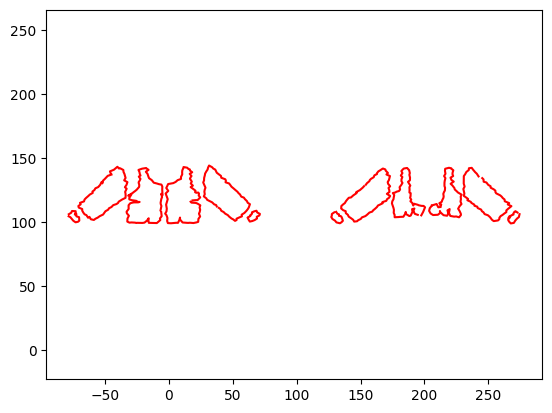

In [ ]:

for i in range(n_components):
    boundary_ids = igl.boundary_loop(all_simplices[components_ids == i])
    boundary_verts = all_verts[boundary_ids]
    plt.plot(boundary_verts[:, 0], boundary_verts[:, 1], color='red')
plt.axis("equal")
plt.show()
plt.close()


In [42]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components as cs_cc
def connected_components(adj_or_edges, n_nodes=None):
    """
    Find connected components of an undirected graph.

    Args:
        adj_or_edges:
            - scipy.sparse CSR matrix of shape (N, N), or
            - edge list ndarray of shape (E, 2) with node ids in [0, N)
        n_nodes (int, optional): required if adj_or_edges is an edge list.

    Returns:
        n_comp (int): number of connected components.
        labels (np.ndarray): shape (N,), labels[i] in [0..n_comp-1] is the component id of node i.
        components (list[np.ndarray]): list of node-index arrays, one per component.
    """
    # ---- SciPy path (fast) ----
    if hasattr(adj_or_edges, "tocsr"):  # sparse adjacency
        A = adj_or_edges.tocsr()
        # ensure symmetry (cheap no-op if already symmetric)
        A = ((A + A.T) > 0).astype(np.uint8)
    else:  # edge list
        edges = np.asarray(adj_or_edges, dtype=np.int64)
        assert edges.ndim == 2 and edges.shape[1] == 2, "edge list must be (E,2)"
        if n_nodes is None:
            n_nodes = int(edges.max()) + 1 if edges.size else 0
        # build symmetric CSR adjacency
        if edges.size == 0:
            A = csr_matrix((n_nodes, n_nodes), dtype=np.uint8)
        else:
            ii = edges[:,0]; jj = edges[:,1]
            data = np.ones(ii.size * 2, dtype=np.uint8)
            rows = np.concatenate([ii, jj])
            cols = np.concatenate([jj, ii])
            A = csr_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes))
            A.data[:] = 1

    n_comp, labels = cs_cc(A, directed=False, return_labels=True)
    components = [np.where(labels == k)[0] for k in range(n_comp)]
    return n_comp, labels, components

n_comp, labels, comps = connected_components(edges)
print("components:", n_comp)
for i, nodes in enumerate(comps):
    print(f"comp {i}: size={nodes.size}")
    print(nodes)

NameError: name 'edges' is not defined

In [16]:
data_folder = "/orion/u/w4756677/garment/gcdv2/garment_particles_v2_10172025"
import glob, os, tqdm, numpy as np
data_folders = glob.glob(os.path.join(data_folder, "rand*"))
print(len(data_folders))
points = []
front_ms = []
front_Ms = []
back_ms = []
back_Ms = []
max_n_points = 8192
max_uv = np.array([150, 200])
min_uv = np.array([-150, -50])
keep = []
valid = 0
for data_folder in tqdm.tqdm(data_folders, desc="Processing data folders"):
    stat = os.path.join(data_folder, "stats.txt")
    if not os.path.exists(stat):
        continue
    valid += 1
    stat = np.loadtxt(stat)
    n_points = stat[0]
    front_m = stat[1:6]
    front_M = stat[6:11]
    back_m = stat[11:16]
    back_M = stat[16:21]
    if n_points > max_n_points:
        continue
    if front_m[0] < min_uv[0] or front_M[0] > max_uv[0] or front_m[1] < min_uv[1] or front_M[1] > max_uv[1]:
        continue
    if back_M[0] < min_uv[0] or back_M[0] > max_uv[0] or back_M[1] < min_uv[1] or back_M[1] > max_uv[1]:
        continue
    
    keep.append(data_folder.split("/")[-1])

print(valid)
n_points = np.array(points)
front_ms = np.array(front_ms)
front_Ms = np.array(front_Ms)
back_ms = np.array(back_ms)
back_Ms = np.array(back_Ms)

print(n_points.shape, front_ms.shape, front_Ms.shape, back_ms.shape, back_Ms.shape)

128974


Processing data folders:   0%|          | 0/128974 [00:00<?, ?it/s]

Processing data folders: 100%|██████████| 128974/128974 [01:09<00:00, 1846.31it/s]

108482
(0,) (0,) (0,) (0,) (0,)


In [14]:
with open("/orion/u/w4756677/garment/InteractGarment/src/assets/garment_particle_v2_filtered_10172025.txt", "w") as f:
    for k in keep:
        f.write(f"{k}/garment_particles_{k}.npz\n")
        

In [ ]:
data_list = open("/orion/u/w4756677/garment/InteractGarment/src/assets/garment_particle_v2_filtered_10172025.txt").readlines()
train_ratio = 0.95
import random
random.shuffle(data_list)
train_data_list = data_list[:int(len(data_list) * train_ratio)]
valid_data_list = data_list[int(len(data_list) * train_ratio):]

with open("/orion/u/w4756677/garment/InteractGarment/src/assets/garment_particle_v2_train_10172025.txt", "w") as f:
    for k in train_data_list:
        f.write(f"{k}")

with open("/orion/u/w4756677/garment/InteractGarment/src/assets/garment_particle_v2_test_10172025.txt", "w") as f:
    for k in valid_data_list:
        f.write(f"{k}")


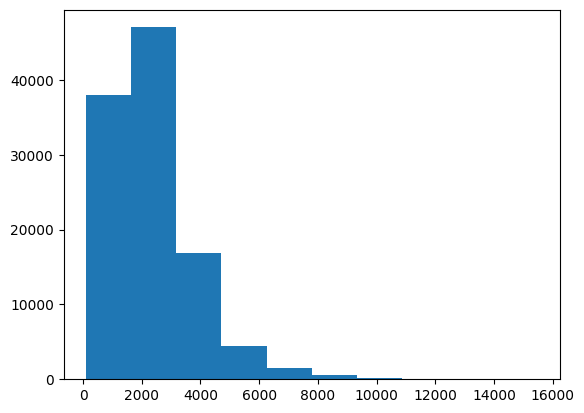

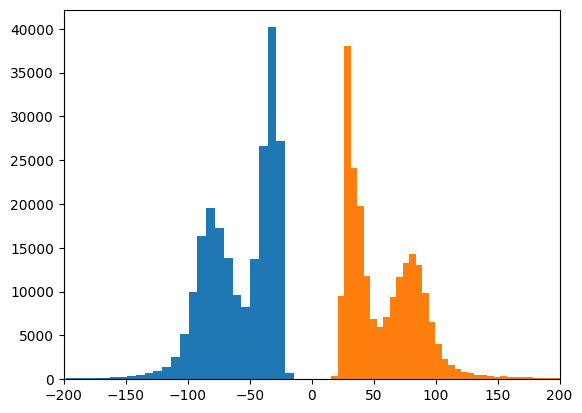

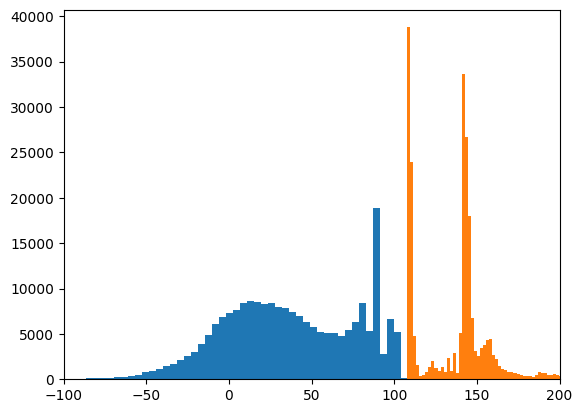

In [10]:
import matplotlib.pyplot as plt
plt.hist(n_points)
plt.show()
plt.close()
plt.hist(np.concatenate([front_ms[:, 0], back_ms[:, 0]]), bins=100)
plt.hist(np.concatenate([front_Ms[:, 0], back_Ms[:, 0]]), bins=100)
plt.xlim(-200, 200)
plt.show()
plt.close()

plt.hist(np.concatenate([front_ms[:, 1], back_ms[:, 1]]), bins=100)
plt.hist(np.concatenate([front_Ms[:, 1], back_Ms[:, 1]]), bins=100)
plt.xlim(-100, 200)
plt.show()
plt.close()

(6, 7)


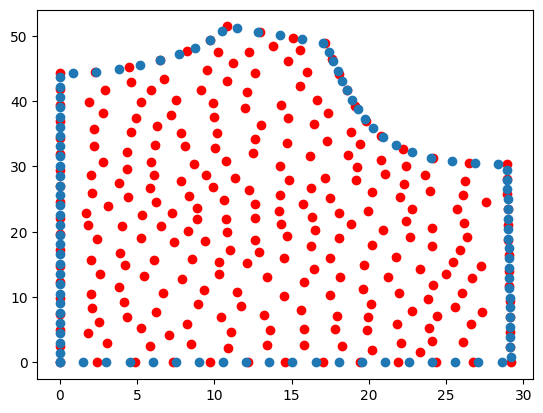

In [41]:
data_folder = "/orion/u/w4756677/garment/gcdv2/panel_edge_vecs/rand_HYT7MMDLE5/panel_edge_vecs_rand_HYT7MMDLE5.npz"
edge_dict = np.load(data_folder)
edge_vecs = edge_dict['left_btorso']
path = get_panel_from_vecs(edge_vecs, 1, 0)
print(edge_vecs.shape)
points = pat_utils.sample_path_arclength(path, num_samples=100)
points -= points.min(0)
left_btorso = pts
left_btorso -= left_btorso.min(0)
plt.scatter(left_btorso[:,0], left_btorso[:,1], c='r')
plt.scatter(points[:,0], points[:,1])
plt.show()

In [ ]:
data_folder = "/orion/u/w4756677/garment/gcdv2/garment_particles_v3.1"
data_files = glob.glob(os.path.join(data_folder, "rand_*"))
count_dict = {}
all_count_list = []
for data_file in tqdm.tqdm(data_files, desc="Processing data files"):
    garment_name = data_file.split("/")[-1].split(".")[0]
    h5_file = os.path.join(data_file, f"garment_particles_{garment_name}.h5")
    if not os.path.exists(h5_file):
        continue
    h5_file = h5py.File(h5_file, 'r')
    count_list = []
    for panel_name in h5_file.keys():
        n_points = 0
        n_points += h5_file[panel_name]["boundary_verts"].shape[0]
        n_points += h5_file[panel_name]["interior_verts"].shape[0]
        count_list.append(n_points)
    all_count_list.extend(count_list)
    count_dict[garment_name] = count_list
with open("total_count.txt", 'w') as f:
    for garment_name, n_points in count_dict.items():
        f.write(f"{garment_name}" + " ".join(map(str, n_points))"\n")
    
    

NameError: name 'glob' is not defined

In [10]:
import glob 
import os 
import random 
from pathlib import Path
import trimesh
import numpy as np
import matplotlib.pyplot as plt
import json 

from pygarment.meshgen.boxmeshgen import BoxMesh
pattern_folder = "/orion/u/w4756677/garment/gcdv2/garmentcodedatav2/garments_5000_27/default_body/rand_89V1B3VHCF"
garment_name = pattern_folder.split('/')[-1]
pattern_spec = Path(pattern_folder) / f'{garment_name}_specification.json'
box_mesh = Path(pattern_folder) / f'{garment_name}_boxmesh.ply'
box_mesh = trimesh.load_mesh(box_mesh)
sim_mesh = Path(pattern_folder) / f'{garment_name}_sim.ply'
sim_mesh = trimesh.load_mesh(sim_mesh)
garment_box_mesh = BoxMesh(pattern_spec, 1)
garment_box_mesh.load()
garment_box_mesh.regen_panel_meshes(256)

# Compute the GCD image statistics
# offsets = json.load(open("/orion/u/w4756677/garment/InteractGarment/external/GarmentCode/test/rand_K8D3T235XT/panel_offsets_rand_K8D3T235XT.json"))


BoxMesh::WARNING::rand_89V1B3VHCF::Provided pattern has self-intersecting panels. Simulation might crash


(249, 2)


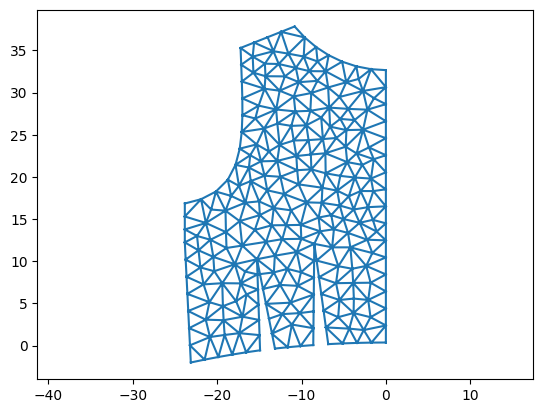

(245, 2)


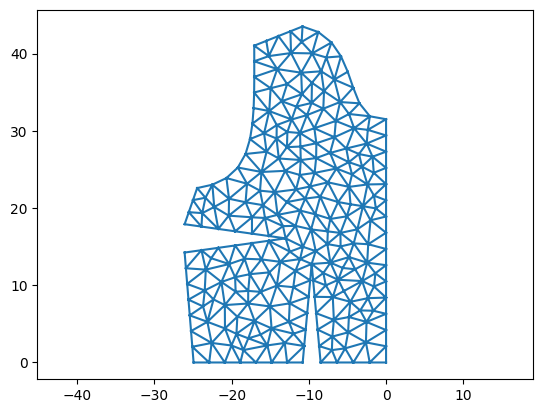

(267, 2)


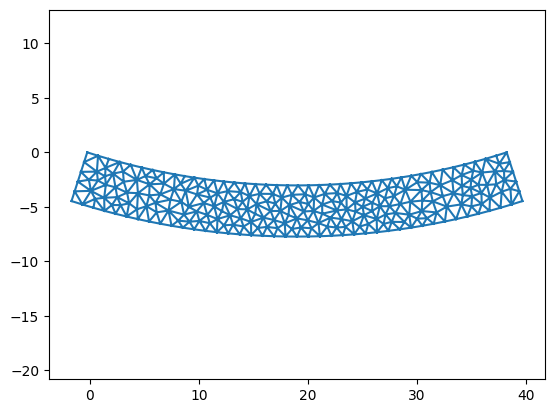

(253, 2)


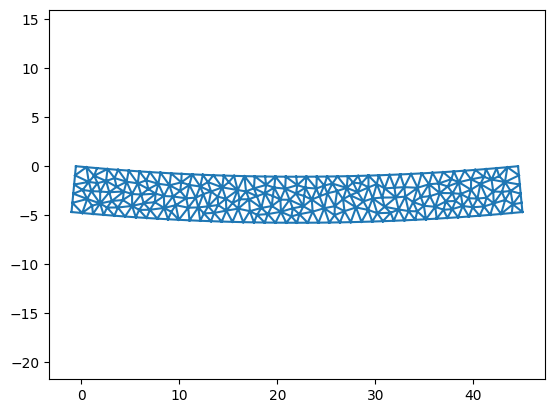

(237, 2)


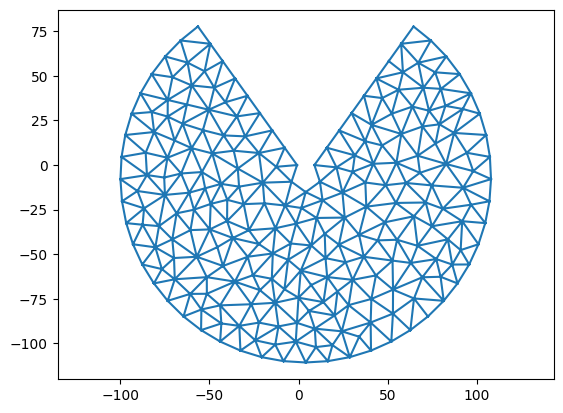

(229, 2)


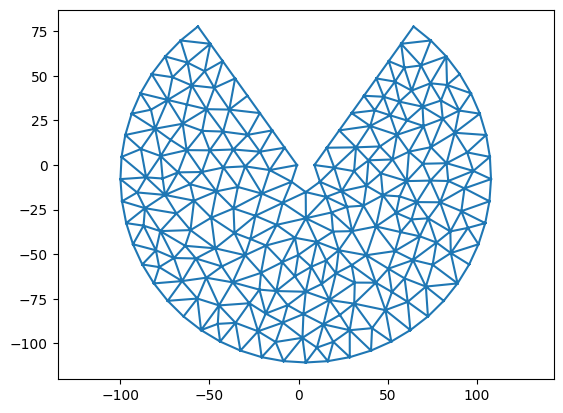

(248, 2)


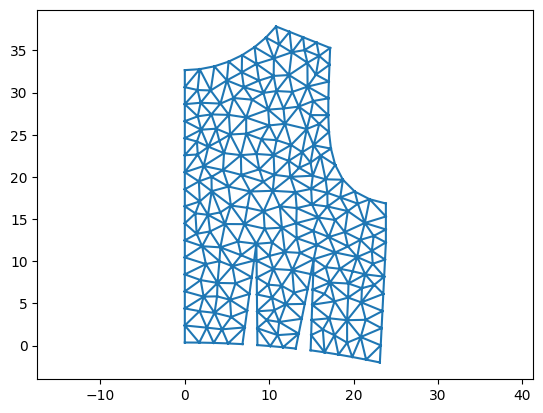

(246, 2)


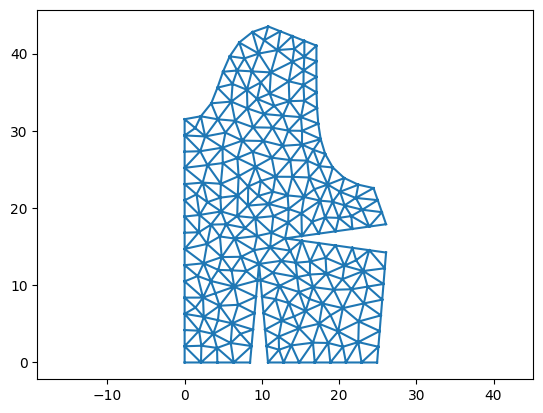

In [11]:
for i, (panel_name, panel) in enumerate(garment_box_mesh.panels.items()):
    verts = panel.panel_vertices
    verts = np.array(verts)
    faces = panel.panel_faces
    faces = np.array(faces)
    print(verts.shape)
    plt.triplot(verts[:,0], verts[:,1], faces)
    plt.axis('equal')
    plt.show()
    plt.close()
    


14346 14346


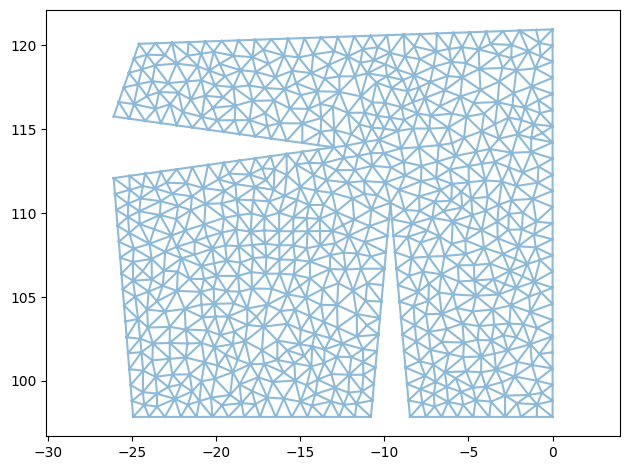

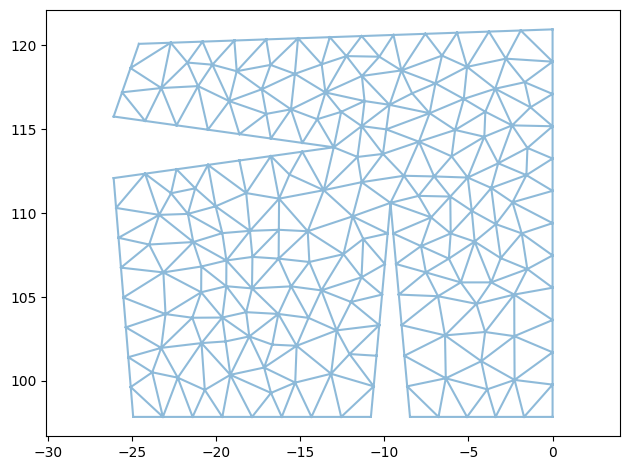

In [ ]:
import igl 

all_verts = []
all_coarse_verts = []
all_coarse_sim_verts = []
all_faces = []
all_coarse_faces = []
face_offset = 0
coarse_face_offset = 0
box_mesh_face_offset = 0
for i, (panel_name, panel) in enumerate(garment_box_mesh.panels.items()):
    is_front = garment_box_mesh.is_front(panel_name)
    if not is_front or "torso" not in panel_name:
        continue
    
    verts = panel.panel_vertices
    verts = np.array(verts)
    flat_rot_angle = garment_box_mesh.vertex_texture[i]['rotation']
    rotation_center = garment_box_mesh.vertex_texture[i]['rotation_center']
    rotation_matrix = np.array([[np.cos(flat_rot_angle), -np.sin(flat_rot_angle)], [np.sin(flat_rot_angle), np.cos(flat_rot_angle)]])
    verts = (rotation_matrix @ (verts - rotation_center)[..., None])[..., 0] + rotation_center + garment_box_mesh.vertex_texture[i]["translation"]
    # verts += offsets[panel_name]
    faces = garment_box_mesh.vertex_texture[i]["face_texture_coords"]
    faces = np.array(faces)
    all_verts.append(verts)
    all_faces.append(faces + face_offset)
    face_offset += len(verts)
    
    coarse_panel = garment_box_mesh_coarse.panels[panel_name]
    coarse_verts = coarse_panel.panel_vertices
    coarse_verts = np.array(coarse_verts)
    coarse_verts = (rotation_matrix @ (coarse_verts - rotation_center)[..., None])[..., 0] + rotation_center + garment_box_mesh.vertex_texture[i]["translation"]
    # coarse_verts += offsets[panel_name]
    coarse_faces = garment_box_mesh_coarse.vertex_texture[i]["face_texture_coords"]
    all_coarse_verts.append(coarse_verts)
    all_coarse_faces.append(coarse_faces + coarse_face_offset)
    coarse_face_offset += len(coarse_verts)
    
    dist, closest_id, closest_pt = igl.point_mesh_squared_distance(
        np.concatenate([coarse_verts, coarse_verts[:, :1]*0], -1), 
        np.concatenate([verts, verts[:, :1]*0], -1), 
        faces
    )
    matched_fine_faces = faces[closest_id]
    matched_fine_verts = verts[matched_fine_faces]
    matched_fine_verts = np.concatenate([
        matched_fine_verts, matched_fine_verts[..., :1]*0
    ], -1)
    bary_coords = igl.barycentric_coordinates(
        np.concatenate([coarse_verts, coarse_verts[:, :1]*0], -1),
        matched_fine_verts[:, 0], 
        matched_fine_verts[:, 1], 
        matched_fine_verts[:, 2]
    )
    
    print(len(garment_box_mesh.faces), sum([len(garment_box_mesh.vertex_texture[i]["face_texture_coords"]) for i in range(len(garment_box_mesh_coarse.vertex_texture))]))
    box_mesh_matched_faces = np.array(garment_box_mesh._get_glob_ids(panel, matched_fine_faces.flatten())).reshape(matched_fine_faces.shape)
    box_mesh_matched_verts = np.array(garment_box_mesh.vertices)[box_mesh_matched_faces].reshape(-1, 3)
    dist = np.linalg.norm(box_mesh_matched_verts[None, ] - box_mesh.vertices[:, None], axis=-1)
    min_indices = np.argmin(dist, axis=0).reshape(box_mesh_matched_faces.shape)
    fine_matched_sim_verts = sim_mesh.vertices[min_indices]
    coarse_sim_verts = np.sum(fine_matched_sim_verts * bary_coords[..., None], axis=1)
    all_coarse_sim_verts.append(coarse_sim_verts)
    break
    
    



verts = np.concatenate(all_verts, axis=0)
faces = np.concatenate(all_faces, axis=0)
m, M = verts.min(), verts.max()

# particles = np.load("/orion/u/w4756677/garment/InteractGarment/external/GarmentCode/garment_particles/rand_2LF3MKC5SB/garment_particles_rand_2LF3MKC5SB.npz")

plt.triplot(verts[:, 0], verts[:, 1], faces, alpha=0.5)
# plt.scatter(particles["inside_pts_front"][:, 0], particles["inside_pts_front"][:, 1], s=0.1, color='red', label='inside')
# plt.scatter(particles["outside_pts_front"][:, 0], particles["outside_pts_front"][:, 1], s=0.1, color='blue', label='outside')
# plt.scatter(particles["interior_verts_front"][:, 0], particles["interior_verts_front"][:, 1], s=0.1, color='green', label='interior')
plt.axis('equal')
plt.tight_layout()
plt.show()
plt.close()

coarse_verts = np.concatenate(all_coarse_verts, axis=0)
coarse_sim_verts = np.concatenate(all_coarse_sim_verts, axis=0)
coarse_faces = np.concatenate(all_coarse_faces, axis=0)
coarse_sim_mesh = trimesh.Trimesh(vertices=coarse_verts, faces=coarse_faces)
coarse_sim_mesh.export("coarse_sim_mesh.obj")
plt.triplot(coarse_verts[:, 0], coarse_verts[:, 1], coarse_faces, alpha=0.5)
# plt.scatter(particles["inside_pts_front"][:, 0], particles["inside_pts_front"][:, 1], s=0.1, color='red', label='inside')
# plt.scatter(particles["outside_pts_front"][:, 0], particles["outside_pts_front"][:, 1], s=0.1, color='blue', label='outside')
# plt.scatter(particles["interior_verts_front"][:, 0], particles["interior_verts_front"][:, 1], s=0.1, color='green', label='interior')
plt.axis('equal')
plt.tight_layout()
plt.show()
plt.close()

In [3]:
import igl 

dist, closest_id, closest_pt = igl.point_mesh_squared_distance(
    np.concatenate([coarse_verts, coarse_verts[:, :1]*0], -1), 
    np.concatenate([verts, verts[:, :1]*0], -1), 
    faces
)
matched_fine_faces = faces[closest_id]
matched_fine_verts = verts[matched_fine_faces]
print(matched_fine_verts.shape)
matched_fine_verts = np.concatenate([
    matched_fine_verts, matched_fine_verts[..., :1]*0
], -1)
bary_coords = igl.barycentric_coordinates(
    np.concatenate([coarse_verts, coarse_verts[:, :1]*0], -1),
    matched_fine_verts[:, 0], 
    matched_fine_verts[:, 1], 
    matched_fine_verts[:, 2]
)

fine_box_mesh_verts = np.array(garment_box_mesh.vertices)
print(len(garment_box_mesh.faces), faces.shape, fine_box_mesh_verts.shape)
dist = np.linalg.norm(fine_box_mesh_verts[None] - box_mesh.vertices[:, None], axis=-1)
print(dist.min(0))
min_indices = np.argmin(dist, axis=0)
print(min_indices.shape, np.unique(min_indices).shape, min_indices.max(), sim_mesh.vertices.shape)
fine_sim_mesh = trimesh.Trimesh(vertices=sim_mesh.vertices[min_indices], faces=faces)
fine_sim_mesh.export("mesh.obj")
sim_vertices = sim_mesh.vertices[min_indices]
interpolated_coarse_sim_verts = np.sum(sim_vertices * bary_coords[..., None], -2)
print(interpolated_coarse_sim_verts.shape)
print(min_indices.shape, fine_box_mesh_verts.shape, sim_vertices.shape)
assert np.allclose(np.clip(bary_coords, None, 0), 0)
plt.triplot(verts[:, 0], verts[:, 1], faces[closest_id], alpha=0.5, color='red')
plt.triplot(coarse_verts[:, 0], coarse_verts[:, 1], coarse_faces, alpha=0.5)
coarse_sim_mesh = trimesh.Trimesh(vertices=interpolated_coarse_sim_verts, faces=coarse_faces)
coarse_sim_mesh.export("coarse_mesh.obj")
# plt.scatter(particles["inside_pts_front"][:, 0], particles["inside_pts_front"][:, 1], s=0.1, color='red', label='inside')
# plt.scatter(particles["outside_pts_front"][:, 0], particles["outside_pts_front"][:, 1], s=0.1, color='blue', label='outside')
# plt.scatter(particles["interior_verts_front"][:, 0], particles["interior_verts_front"][:, 1], s=0.1, color='green', label='interior')
plt.axis('equal')
plt.tight_layout()
plt.show()
plt.close()

(1477, 3, 2)
20640 (9894, 3) (10476, 3)
[1.08009084e-06 3.05422163e-06 2.03610270e-06 ... 1.15711768e-06
 8.65260663e-07 7.98076148e-07]
(10476,) (10476,) 11186 (11187, 3)


ValueError: operands could not be broadcast together with shapes (10476,3) (1477,3,1) 

In [27]:
print(includes)
print(includess)

['/orion/u/w4756677/garment/gcdv2/garmentcodedatav2/garments_5000_5/default_body/rand_BX135JHA0F', '/orion/u/w4756677/garment/gcdv2/garmentcodedatav2/garments_5000_5/default_body/rand_K8D3T235XT', '/orion/u/w4756677/garment/gcdv2/garmentcodedatav2/garments_5000_5/default_body/rand_DQ4DIUFBBC', '/orion/u/w4756677/garment/gcdv2/garmentcodedatav2/garments_5000_5/default_body/rand_IE1YZ42LV9', '/orion/u/w4756677/garment/gcdv2/garmentcodedatav2/garments_5000_5/default_body/rand_5K1VSHO8BY', '/orion/u/w4756677/garment/gcdv2/garmentcodedatav2/garments_5000_5/default_body/rand_SKAL2AKT7Q', '/orion/u/w4756677/garment/gcdv2/garmentcodedatav2/garments_5000_5/default_body/rand_ALREAI0T9D', '/orion/u/w4756677/garment/gcdv2/garmentcodedatav2/garments_5000_5/default_body/rand_ENE8Y61Q43', '/orion/u/w4756677/garment/gcdv2/garmentcodedatav2/garments_5000_5/default_body/rand_MWGFSIAB1O', '/orion/u/w4756677/garment/gcdv2/garmentcodedatav2/garments_5000_5/default_body/rand_RUNGU7JBRD', '/orion/u/w4756677/

1328


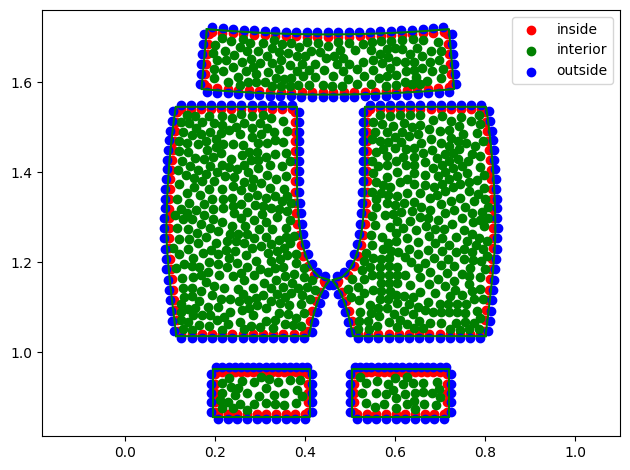

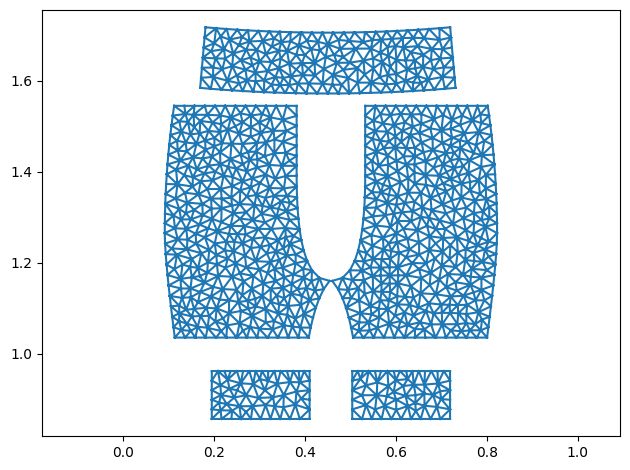

In [4]:
import igl 
from shapely.geometry import Polygon
from shapely import Point
def get_line_from_normal(normal, p):
    line_dir = np.array([-normal[1], normal[0]])
    line_dir = line_dir / np.linalg.norm(line_dir)
    return lambda t: p + t * line_dir
polys = []
all_verts = []
all_faces = []
all_boundary_verts = []
all_interior_verts_list = []
all_inside_pts = []
all_outside_pts = []
face_offset = 0
for i, (panel_name, panel) in enumerate(garment_box_mesh.panels.items()):
    is_front = garment_box_mesh.is_front(panel_name)
    if not is_front:
        continue
    is_front = garment_box_mesh.is_front(panel_name)
    verts = panel.panel_vertices
    verts = np.array(verts)
    faces = panel.panel_faces
    faces = np.array(faces)
    flat_rot_angle = garment_box_mesh.vertex_texture[i]['rotation']
    rotation_center = garment_box_mesh.vertex_texture[i]['rotation_center']
    rotation_matrix = np.array([[np.cos(flat_rot_angle), -np.sin(flat_rot_angle)], [np.sin(flat_rot_angle), np.cos(flat_rot_angle)]])
    verts = (rotation_matrix @ (verts - rotation_center)[..., None])[..., 0] + rotation_center + garment_box_mesh.vertex_texture[i]["translation"]
    if panel_name == "right_ftorso":
        verts[:, 0] -= 3
    if panel_name == "left_ftorso":
        verts[:, 0] += 3
    if panel_name == "wb_front":
        verts[:, 1] -= 3
    verts = (verts - m) / (M - m)
    all_verts.append(verts)
    all_faces.append(faces + face_offset)
    face_offset += len(verts)
    boundary_verts = []
    boundary_ids = []
    boundary_verts = []
    inside_pts = []
    outside_pts = []
    eps = 0.005
    for edge_id, edge in enumerate(garment_box_mesh.panels[panel_name].edges):
        boundary_ids.append(edge.vertex_range)
        edge_verts = verts[edge.vertex_range]
        boundary_verts.append(edge_verts[:-1])
        lines = []
        is_dart_and_skip = False
        target_edge = None
        for seam in garment_box_mesh.stitches:
            if seam.panel_1 == seam.panel_2 == panel_name and (seam.edge_1 == edge_id or seam.edge_2 == edge_id):
                target_edge = seam.edge_2
                if seam.edge_2 == edge_id:
                    is_dart_and_skip = True
                break
        for i in range(len(edge_verts)-1):
            p1 = edge_verts[i]
            p2 = edge_verts[i+1]
            normal = np.array([p2[0] - p1[0], p2[1] - p1[1]])
            normal = normal / np.linalg.norm(normal)
            line = get_line_from_normal(normal, (p1 + p2) / 2)
            lines.append(line)
            inside_pts.append(line(eps))
            if target_edge is None:
                outside_pts.append(line(-eps))
            else:
                # dart 
                if is_dart_and_skip:
                    continue
                n_verts = len(edge_verts)
                next_edge = garment_box_mesh.panels[panel_name].edges[target_edge]
                next_edge_verts = verts[next_edge.vertex_range]
                next_p1 = next_edge_verts[n_verts - 1 - i]
                next_p2 = next_edge_verts[n_verts - i - 2]
                mid_p1 = (p1 + next_p1) / 2
                mid_p2 = (p2 + next_p2) / 2
                outside_pts.append((mid_p1 + mid_p2) / 2)
            
    
    boundary_verts = np.concatenate(boundary_verts, axis=0)
    boundary_verts = np.concatenate([boundary_verts, boundary_verts[0:1]], axis=0)
    plt.plot(boundary_verts[:, 0], boundary_verts[:, 1], color='green')
    # plt.scatter(boundary_verts[:, 0], boundary_verts[:, 1], color='red')
    boundary_ids = np.concatenate(boundary_ids, axis=0)
    interior_verts = verts[np.setdiff1d(np.arange(len(verts)), boundary_ids)]
    all_interior_verts_list.append(interior_verts)
    poly = Polygon(boundary_verts)
    
    # inside_pts = []
    # outside_pts = []
    # eps = 0.001
    # for i in range(len(boundary_verts)-1):
    #     p1 = boundary_verts[i]
    #     p2 = boundary_verts[i+1]
    #     normal = np.array([p2[0] - p1[0], p2[1] - p1[1]])
    #     normal = normal / np.linalg.norm(normal)
    #     line = get_line_from_normal(normal, (p1 + p2) / 2)
    #     inside_pts.append(line(eps))
    #     outside_pts.append(line(-eps))
    _inside_pts = np.array(inside_pts)
    _outside_pts = np.array(outside_pts)
    in_contain_flags = [poly.contains(Point(_inside_pts[i])) for i in range(len(_inside_pts))]
    out_contain_flags = [poly.contains(Point(_outside_pts[i])) for i in range(len(_outside_pts))]
    inside_pts = np.stack([p for i, p in enumerate(_inside_pts) if in_contain_flags[i]])
    outside_pts = np.stack([p for i, p in enumerate(_outside_pts) if not out_contain_flags[i]])
    
    all_inside_pts.append(inside_pts)
    all_outside_pts.append(outside_pts)

all_inside_pts = np.concatenate(all_inside_pts, axis=0)
all_outside_pts = np.concatenate(all_outside_pts, axis=0)
all_interior_verts = np.concatenate(all_interior_verts_list, axis=0)
print(all_inside_pts.shape[0] + all_outside_pts.shape[0] + all_interior_verts.shape[0])
plt.scatter(all_inside_pts[:, 0], all_inside_pts[:, 1], color='red', label='inside')
plt.scatter(all_interior_verts[:, 0], all_interior_verts[:, 1], color='green', label='interior')
plt.scatter(all_outside_pts[:, 0], all_outside_pts[:, 1], color='blue', label='outside')
# Set equal aspect ratio
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

all_verts = np.concatenate(all_verts, axis=0)
all_faces = np.concatenate(all_faces, axis=0)
plt.triplot(all_verts[:, 0], all_verts[:, 1], all_faces)
plt.axis('equal')
plt.tight_layout()
plt.show()
plt.close()


In [116]:
# --------------------- CDT via Triangle (PSLG input) ----------------------- #
import triangle as tr
from dataclasses import dataclass
from typing import Optional, List, Tuple, Dict
from shapely.geometry import Polygon

# ---------------------------- Geometry helpers ---------------------------- #

def _ensure_ccw(ring: np.ndarray) -> np.ndarray:
    """Ensure ring (Nx2, open or closed) is CCW; return as OPEN ring."""
    ring = np.asarray(ring, dtype=float)
    if ring.ndim != 2 or ring.shape[1] != 2 or ring.shape[0] < 3:
        raise ValueError("ring must be (N,2) with N >= 3")

    # If closed, make it open for consistent processing
    if np.allclose(ring[0], ring[-1]):
        ring = ring[:-1]

    # Shoelace signed area (positive => CCW)
    x = ring[:, 0]
    y = ring[:, 1]
    area2 = np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))

    return ring if area2 > 0 else ring[::-1]


def _ring_segments(indices: List[int]) -> List[Tuple[int, int]]:
    """Return segment index pairs to close the ring."""
    segs = []
    n = len(indices)
    for i in range(n):
        segs.append((indices[i], indices[(i + 1) % n]))
    return segs


def _point_in_ring_centroid(ring: np.ndarray) -> Tuple[float, float]:
    """A point guaranteed inside the hole ring (use polygon centroid)."""
    poly = Polygon(ring)
    c = poly.representative_point()  # always inside
    return (c.x, c.y)


def _dedup_points(points: List[Tuple[float, float]], tol=0.0) -> Tuple[np.ndarray, Dict[Tuple[float, float], int]]:
    """Deduplicate points; return (unique Nx2 array, mapping original->index).
       If tol>0, round coordinates to that many decimals before dedup."""
    idx_map: Dict[Tuple[float, float], int] = {}
    unique = []
    for p in points:
        key = p if tol == 0 else (round(p[0], tol), round(p[1], tol))
        if key not in idx_map:
            idx_map[key] = len(unique)
            unique.append(p)
    return np.asarray(unique, dtype=float), idx_map

@dataclass
class CDTResult:
    vertices: np.ndarray          # (N, 2)
    triangles: np.ndarray         # (T, 3) vertex indices
    segments: np.ndarray          # (M, 2) boundary segment indices (outer + holes)


def constrained_delaunay_triangulation(
    outer_ring: np.ndarray,
    holes: Optional[List[np.ndarray]] = None,
    interior_points: Optional[np.ndarray] = None,
    min_angle: float = 25.0,
    max_area: Optional[float] = None,
) -> CDTResult:
    """
    Build a CDT of a polygon with optional holes and optional interior points.
    Uses the 'triangle' package (Shewchuk's Triangle).

    Parameters
    ----------
    outer_ring : (N,2) ndarray, CCW open or closed
    holes : list of (H_i,2) ndarrays (each hole ring CW or CCW; orientation will be fixed)
    interior_points : (K,2) ndarray of extra points to include as vertices
    min_angle : float, quality constraint (degrees)
    max_area : optional float, area upper bound per triangle

    Returns
    -------
    CDTResult
    """

    outer = _ensure_ccw(np.asarray(outer_ring, dtype=float))
    holes = holes or []
    holes = [_ensure_ccw(np.asarray(h, dtype=float)) for h in holes]

    # Build PSLG: unique vertices + segments
    all_coords: List[Tuple[float, float]] = []
    outer_idx = []
    for p in outer:
        all_coords.append((float(p[0]), float(p[1])))
        outer_idx.append(len(all_coords) - 1)

    hole_indices = []
    for h in holes:
        idxs = []
        for p in h:
            all_coords.append((float(p[0]), float(p[1])))
            idxs.append(len(all_coords) - 1)
        hole_indices.append(idxs)

    # Deduplicate in case rings share points
    V, mapping = _dedup_points(all_coords, tol=12)

    # Rebuild index lists after dedup
    def remap(idxs_raw: List[int]) -> List[int]:
        remapped = []
        for k in idxs_raw:
            key = all_coords[k]
            keyr = (round(key[0], 12), round(key[1], 12))
            remapped.append(mapping[keyr] if keyr in mapping else mapping[key])
        return remapped

    outer_idx = remap(outer_idx)
    holes_idx = [remap(idxs) for idxs in hole_indices]

    segs = _ring_segments(outer_idx)
    for idxs in holes_idx:
        segs += _ring_segments(idxs)

    # Triangle expects "holes" as a point INSIDE each hole polygon
    triangle_holes = []
    for h in holes:
        triangle_holes.append(_point_in_ring_centroid(h))

    # Add interior points (forced vertices) if provided
    if interior_points is not None and len(interior_points) > 0:
        interior_points = np.asarray(interior_points, dtype=float)
        V = np.vstack([V, interior_points])

    A = dict(vertices=V, segments=np.asarray(segs, dtype=int))
    if len(triangle_holes) > 0:
        A["holes"] = np.asarray(triangle_holes, dtype=float)

    # Triangle options:
    #  p : PSLG input       D : constrained Delaunay
    #  qXX : min angle      aXX : max area
    opts = f"p"
    # if max_area is not None and max_area > 0:
    #     opts += f"a{max_area}"

    T = tr.triangulate(A, opts)

    verts = np.asarray(T["vertices"], dtype=float)
    tris = np.asarray(T["triangles"], dtype=int)
    segs_out = np.asarray(T["segments"], dtype=int) if "segments" in T else np.asarray(segs, dtype=int)

    return CDTResult(vertices=verts, triangles=tris, segments=segs_out)

In [117]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim 
boundary_verts_cuda = torch.from_numpy(boundary_verts).cuda()
inside_pts_cuda = torch.from_numpy(all_inside_pts).cuda()
outside_pts_cuda = torch.from_numpy(all_outside_pts).cuda()
inside_pts_cuda.requires_grad = True
outside_pts_cuda.requires_grad = True
optimizer = optim.Adam([inside_pts_cuda, outside_pts_cuda], lr=0.001)
def dist_to_line(x, normal, point):
    """
    Corrected implementation
    x: [N, 2]
    normal: [N, K, 2] 
    point: [N, K, 2]
    return: [N, K]
    """
    # Compute dot product: (x - point) · normal for each x and each line
    dot_products = torch.sum((x.unsqueeze(1) - point) * normal, dim=-1)
    # Take absolute value and normalize by normal magnitude
    return torch.abs(dot_products) / torch.norm(normal, dim=-1)

def loss_fn(x, in_pts, out_pts):
    """
    x: [N, 2]
    in_pts: [M, 2]
    out_pts: [K, 2]
    """
    dist_to_in = torch.norm(x.unsqueeze(1) - in_pts, dim=2)
    matched_in_ids = torch.argmin(dist_to_in, dim=1)
    matched_in_pts = in_pts[matched_in_ids]
    
    normals = F.normalize(matched_in_pts.unsqueeze(1) - out_pts, dim=2) # [N, K, 2]
    mid_points = (matched_in_pts.unsqueeze(1) + out_pts) / 2 # [N, K, 2]
    dist_to_bisector = dist_to_line(x, normals, mid_points) # [N, K]
    
    loss = dist_to_bisector.amin(1)
    loss = loss.mean()
    return loss 

def sample_points_from_curve(verts, num_points):
    n_curves = verts.shape[0] - 1
    lengths = torch.norm(verts[1:] - verts[:-1], dim=1)
    total_length = torch.sum(lengths)
    lengths = lengths / total_length
    n_points_per_curve = (lengths * num_points).int()
    ts_per_curve = [torch.linspace(0, 1, n_points_per_curve[i]).cuda() for i in range(n_curves)]
    points = torch.cat([(1 - ts_per_curve[i].unsqueeze(-1)) * verts[i] + ts_per_curve[i].unsqueeze(-1) * verts[i+1] for i in range(len(ts_per_curve))])
    return points

n_points = 1000
for i in range(200):
    x = sample_points_from_curve(boundary_verts_cuda, n_points)
    x = x.cuda()
    loss = loss_fn(x, inside_pts_cuda, outside_pts_cuda)
    if loss < 0.0002:
        break
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Step: {i}: Loss: {loss}")
    plt.scatter(inside_pts_cuda.detach().cpu().numpy()[:, 0], inside_pts_cuda.detach().cpu().numpy()[:, 1])
    plt.scatter(outside_pts_cuda.detach().cpu().numpy()[:, 0], outside_pts_cuda.detach().cpu().numpy()[:, 1])
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(f"opt/step_{i}.png")
    plt.close()
    

In [118]:
import numpy as np
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, MultiPoint, LineString, MultiLineString, box
from shapely.ops import unary_union, polygonize, linemerge

# ----------------------------
# Utilities
# ----------------------------
def _perp(v):
    return np.array([v[1], -v[0]])

def _voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruct finite Voronoi polygons from scipy.spatial.Voronoi (2D).
    Returns:
        regions: list of lists of vertex indices for each point's region (all finite)
        vertices: ndarray of vertices (possibly augmented)
    """
    if vor.points.shape[1] != 2:
        raise ValueError("Supports 2D only.")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = vor.points.ptp().max() * 2.0

    # Map point index -> list of (neighbor_point_index, v1, v2) for each ridge
    all_ridges = {}
    for (p, q), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p, []).append((q, v1, v2))
        all_ridges.setdefault(q, []).append((p, v1, v2))

    for p, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        if -1 not in region:
            # Already finite
            new_regions.append(region)
            continue

        # Rebuild region by extending infinite ridges
        ridges = all_ridges[p]
        new_region = [v for v in region if v != -1]

        for q, v1, v2 in ridges:
            if v1 == -1 or v2 == -1:
                # One vertex at infinity; need to create a "far" vertex
                t = vor.points[q] - vor.points[p]
                t /= np.linalg.norm(t)
                n = _perp(t)  # normal to bisector (direction along ridge)

                # Midpoint of the two generators
                midpoint = (vor.points[p] + vor.points[q]) * 0.5
                # Choose direction that goes "away" from diagram center
                direction = np.sign(np.dot(midpoint - center, n)) * n

                # Finite vertex (the one that's not -1), use it as base
                v_finite = v1 if v1 != -1 else v2
                v_point = vor.vertices[v_finite]
                far_point = v_point + direction * radius

                new_vertices.append(far_point.tolist())
                new_region.append(len(new_vertices) - 1)

        # Order region vertices counterclockwise
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:,1] - c[1], vs[:,0] - c[0])
        new_region = [v for _, v in sorted(zip(angles, new_region))]
        new_regions.append(new_region)

    return new_regions, np.asarray(new_vertices)

def _make_bbox(points, scale=1.3):
    pts = np.vstack(points)
    minx, miny = pts.min(axis=0)
    maxx, maxy = pts.max(axis=0)
    cx, cy = (minx + maxx) / 2.0, (miny + maxy) / 2.0
    w, h = (maxx - minx), (maxy - miny)
    w = max(w, 1e-6)
    h = max(h, 1e-6)
    # pad box
    w2, h2 = (w * scale) / 2.0, (h * scale) / 2.0
    return box(cx - w2, cy - h2, cx + w2, cy + h2)

# ----------------------------
# Main: bisector & regions
# ----------------------------
def bichromatic_voronoi_separator(A, B, bbox=None, bbox_scale=1.5):
    """
    Compute polygons for regions closer to A and closer to B (nearest-neighbor distance),
    and their shared bisector polyline(s) within a bounding window.

    Args:
        A, B: (n,2) numpy arrays
        bbox: optional shapely Polygon for clipping; if None, a padded box is used
        bbox_scale: scale for automatic bbox if bbox is None

    Returns:
        regionA_poly (shapely geometry): polygon/multipolygon - points closer to A than B
        regionB_poly (shapely geometry): polygon/multipolygon - points closer to B than A
        bisector (MultiLineString): lines equidistant to nearest A vs B (the separator)
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    assert A.ndim == 2 and B.ndim == 2 and A.shape[1] == 2 and B.shape[1] == 2

    all_pts = np.vstack([A, B])
    labels = np.hstack([np.zeros(len(A), dtype=int), np.ones(len(B), dtype=int)])

    if bbox is None:
        bbox = _make_bbox(all_pts, scale=bbox_scale)

    # Voronoi diagram for all points
    vor = Voronoi(all_pts)
    regions, vertices = _voronoi_finite_polygons_2d(vor, radius=max(bbox.bounds[2]-bbox.bounds[0],
                                                                    bbox.bounds[3]-bbox.bounds[1]) * 2.0)

    # Build clipped region polygon for each site
    polys_A = []
    polys_B = []
    for i, reg in enumerate(regions):
        poly = Polygon(vertices[reg])
        if not poly.is_valid or poly.is_empty:
            continue
        poly = poly.intersection(bbox)
        if poly.is_empty:
            continue
        if labels[i] == 0:
            polys_A.append(poly)
        else:
            polys_B.append(poly)

    regionA = unary_union(polys_A).intersection(bbox) if polys_A else Polygon()
    regionB = unary_union(polys_B).intersection(bbox) if polys_B else Polygon()

    # The separator is the shared boundary between regionA and regionB
    # (could be multiple disjoint lines)
    bisector = regionA.boundary.intersection(regionB.boundary)
    if isinstance(bisector, LineString):
        bisector = MultiLineString([bisector])
    elif bisector.is_empty:
        bisector = MultiLineString([])

    return regionA, regionB, bisector


/tmp/user/22321/ipykernel_35423/168395203.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


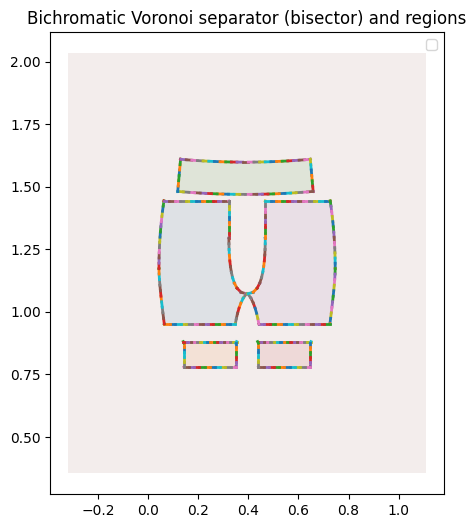

In [120]:
optimized_inside_pts = inside_pts_cuda.detach().cpu().numpy()
# optimized_inside_pts = all_inside_pts
optimized_inside_pts = np.concatenate([optimized_inside_pts, all_interior_verts], axis=0)
optimized_outside_pts = outside_pts_cuda.detach().cpu().numpy()
# optimized_outside_pts = all_outside_pts
regionA, regionB, bis = bichromatic_voronoi_separator(optimized_inside_pts, optimized_outside_pts, bbox=None, bbox_scale=2.0)

# Quick check: plot with matplotlib (optional)
fig, ax = plt.subplots(figsize=(6,6))
# ax.scatter(optimized_inside_pts[:,0], optimized_inside_pts[:,1], marker='o', label='A', zorder=3)
# ax.scatter(optimized_outside_pts[:,0], optimized_outside_pts[:,1], marker='^', label='B', zorder=3)

# Plot regions
for geom, alpha, lw in [(regionA, 0.1, 1.0), (regionB, 0.1, 1.0)]:
    if geom.is_empty: continue
    if geom.geom_type == "Polygon":
        xs, ys = geom.exterior.xy
        ax.fill(xs, ys, alpha=alpha)
    else:
        for g in geom.geoms:
            xs, ys = g.exterior.xy
            ax.fill(xs, ys, alpha=alpha)

# Plot bisector lines
start_point = np.array(bis.geoms[0].xy).T[0]
verts = [[start_point]]
polys = []
if not bis.is_empty:
    if bis.geom_type == "MultiLineString":
        for ls in bis.geoms:
            xs, ys = ls.xy
            if xs[0] == verts[-1][-1][0] and ys[0] == verts[-1][-1][1]:
                verts[-1].append(np.array([xs[1], ys[1]]))
            else:
                verts[-1] = np.array(verts[-1])
                polys.append(Polygon(verts[-1]))
                verts.append([np.array([xs[0], ys[0]]), np.array([xs[1], ys[1]])])
            ax.plot(xs, ys, linewidth=2)
        verts[-1] = np.array(verts[-1])
        polys.append(Polygon(verts[-1]))
    else:
        xs, ys = bis.xy
        ax.plot(xs, ys, linewidth=2)



from collections import defaultdict
all_interior_verts_list = defaultdict(list)
for interior_verts in all_interior_verts:
    for i, poly in enumerate(polys):
        if poly.contains(Point(interior_verts)):
            all_interior_verts_list[i].append(interior_verts)
all_interior_verts_list = {k: np.stack(v, axis=0) for k, v in all_interior_verts_list.items()}
ax.set_aspect('equal', 'box')
ax.legend()
ax.set_title("Bichromatic Voronoi separator (bisector) and regions")
plt.show()
plt.close()

301


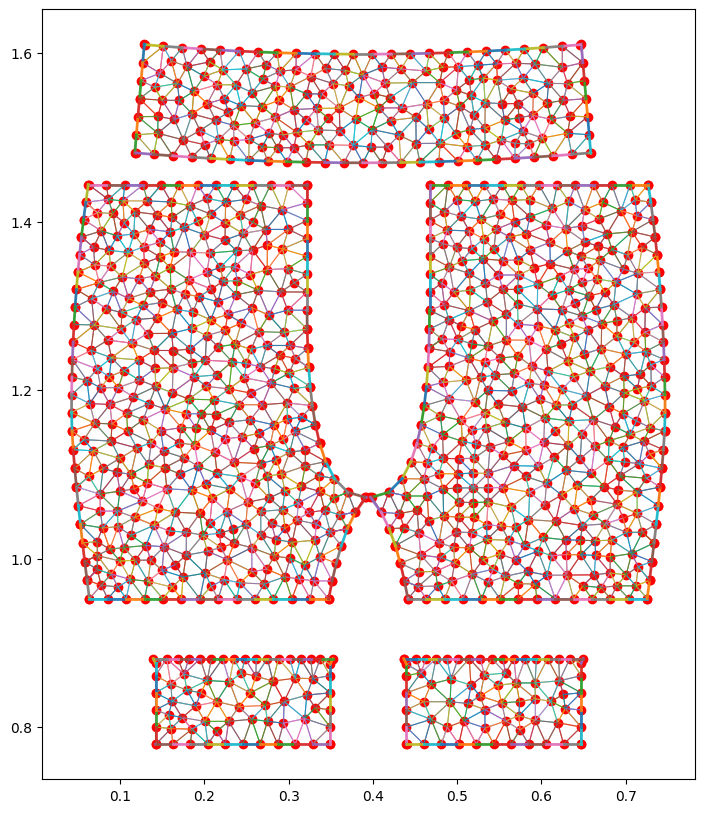

In [121]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal', adjustable='box')
assert len(verts) == len(all_interior_verts_list)
for i, vertss in enumerate(verts):
    interior_verts = all_interior_verts_list[i]
    cdt = constrained_delaunay_triangulation(
        outer_ring=vertss,
        holes=[],
        interior_points=interior_verts,   # or sites if you want to force them in CDT
        min_angle=27.0,
        max_area=None,
    )
    V = cdt.vertices
    for tri in cdt.triangles:
        poly = Polygon(V[tri])
        x, y = poly.exterior.xy
        ax.plot(x, y, lw=0.8, alpha=0.8)
    # boundary segments emphasized
    for a, b in cdt.segments:
        ax.plot([V[a, 0], V[b, 0]], [V[a, 1], V[b, 1]], lw=2.0, alpha=0.9)
    ax.scatter(interior_verts[:, 0], interior_verts[:, 1], color='red', label='inside')
    ax.scatter(vertss[:, 0], vertss[:, 1], color='red', label='inside')
print(len(verts) + len(interior_verts))
plt.show()

In [76]:
for edge in right_ftorso.edges:
    print(edge.endpoints)
print(len(right_ftorso.edges))

[[ 0.          0.        ]
 [ 0.         32.32766778]]
[[ 0.         32.32766778]
 [-8.7483503  32.32766778]]
[[-8.7483503  32.32766778]
 [-4.86445015 45.87243727]]
[[ -4.86445015  45.87243727]
 [-17.0685933   41.02132059]]
[[-17.0685933   41.02132059]
 [-17.06414895  40.53368445]]
[[-17.06414895  40.53368445]
 [-26.03432579  18.04126572]]
[[-26.03432579  18.04126572]
 [-26.0823      17.90286664]]
[[-26.0823      17.90286664]
 [-13.00346875  16.06836664]]
[[-13.00346875  16.06836664]
 [-26.0823      14.23386664]]
[[-26.0823      14.23386664]
 [-24.9212       0.        ]]
[[-2.49212000e+01  0.00000000e+00]
 [-1.07953501e+01  2.84387480e-16]]
[[-1.07953501e+01  2.84387480e-16]
 [-9.63425013e+00  1.27577523e+01]]
[[-9.63425013 12.75775233]
 [-8.47315013  0.        ]]
[[-8.47315013  0.        ]
 [ 0.          0.        ]]
14


In [ ]:
def sort_edges(edges):
    lb_edge = edges[0]
        for edge in edges:
            if (
                sum(edge.endpoints[0])
                < sum(lb_edge.endpoints[0])
            ):
                lb_edge = edge
        # sort the seams
        sorted_edges = []
        sorted_edges.append(lb_edge)
        while len(sorted_edges) < len(edges):
            last_edge: sorted_edges[-1]
            for edge in edges:
                if np.all(last_edge.endpoints[1] == edge.endpoints[0]):
                    sorted_seams.append(seam)
        return sorted_seams

14 [np.int64(198), array([1., 0.])]


/tmp/user/22321/ipykernel_851287/1477706756.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  set20 = cm.get_cmap('Set2', 20)


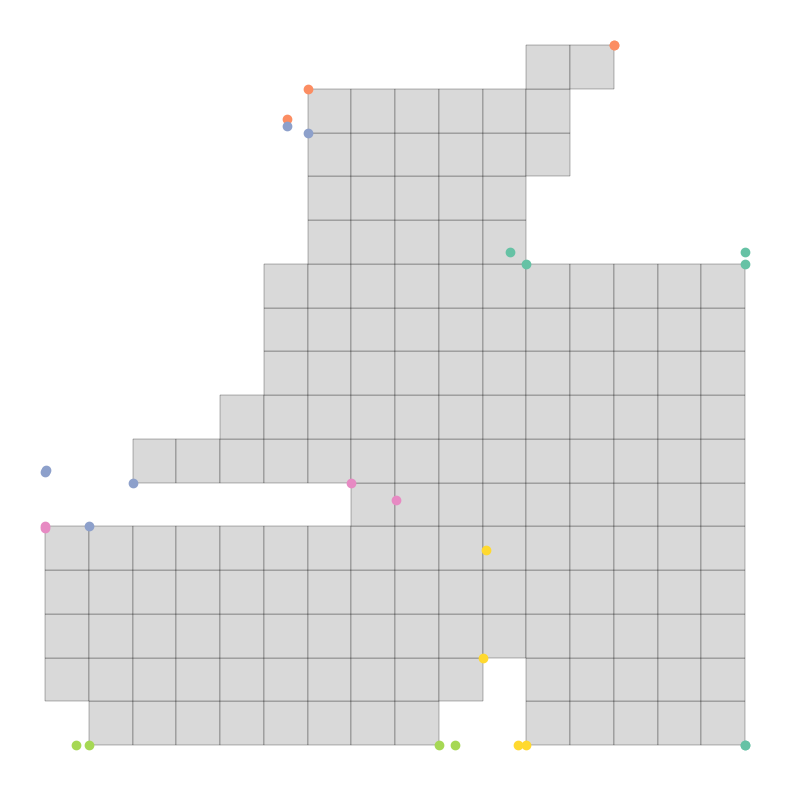

In [ ]:
# First make sure the corners are matched. 
edges = right_ftorso.edges
edges = sort_edges(edges)
panel_corner_verts = (right_ftorso.corner_vertices - m) / (M - m)
matched_bnd_GV_ids = match_B_to_A(bnd_GV, panel_corner_verts)
matched_bnd_GV = bnd_GV[matched_bnd_GV_ids]

# Then match the other boundary vertices to the boundary 
unmatched_bnd_GV_ids = np.setdiff1d(np.arange(len(bnd_GV)), matched_bnd_GV_ids)
unmatched_bnd_GV = bnd_GV[unmatched_bnd_GV_ids]
bnd_V = V[igl.boundary_loop(F)]
matched_unmatched_bnd_GV_ids = match_B_to_A(bnd_V, unmatched_bnd_GV)
matched_bnd_V = bnd_V[matched_unmatched_bnd_GV_ids]

bnd_GV_id2GV_id = {}

constraints = []
for i, (bnd_vert_id, corner_vert) in enumerate(zip(matched_bnd_GV_ids, panel_corner_verts)):
    constraints.append([bnd_ids[bnd_vert_id], corner_vert])
    
# for i, (bnd_vert_id, corner_vert) in enumerate(zip(unmatched_bnd_GV_ids, matched_bnd_V)):
#     constraints.append([bnd_ids[bnd_vert_id], corner_vert])

print(len(constraints), constraints[0])

# visualize
set20 = cm.get_cmap('Set2', 20)
fig, ax = plt.subplots(figsize=(10, 10))
ax, _ = plot_quad_mesh(quad_V, quad_F, ax=ax)
for i, (bnd_vert_id, target_vert) in enumerate(constraints):
    bnd_vert = quad_V[bnd_vert_id]
    ax.scatter(bnd_vert[0], bnd_vert[1], color=set20(i % 20))
    ax.scatter(target_vert[0], target_vert[1], color=set20(i % 20))
    
plt.show()


# Calculate Deformation

In [69]:
def quad_edges(F):
    """
    Compute the unique undirected edges of a quad mesh and the per-face mapping.

    Args
    ----
    F : (M, 4) int array
        Quad faces as vertex indices.

    Returns
    -------
    E  : (K, 2) int array
        Unique undirected edges (u < v).
    FE : (M, 4) int array
        For each face (row of F), indices into E of its 4 edges in order:
        [(v0,v1), (v1,v2), (v2,v3), (v3,v0)].
    is_boundary : (K,) bool array
        True for edges that belong to exactly one face (mesh boundary).
    """
    F = np.asarray(F, dtype=np.int64)
    if F.ndim != 2 or F.shape[1] != 4:
        raise ValueError("F must be an (M,4) array of quad faces.")

    # Oriented edges per face: (M,4,2)
    ef = np.stack([F[:, [0,1]], F[:, [1,2]], F[:, [2,3]], F[:, [3,0]]], axis=1)

    # Canonicalize to undirected and deduplicate
    undirected = np.sort(ef.reshape(-1, 2), axis=1)     # (M*4, 2), each as (min,max)
    E, inv = np.unique(undirected, axis=0, return_inverse=True)  # E: (K,2)
    FE = inv.reshape(-1, 4)                             # (M,4) edge IDs per face

    # Boundary edges: those used by exactly one face
    counts = np.bincount(FE.ravel(), minlength=len(E))
    is_boundary = counts == 1

    return E, FE, is_boundary

/tmp/user/22321/ipykernel_851287/762601071.py:40: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  xs = spsolve(L, Bx)
/tmp/user/22321/ipykernel_851287/762601071.py:41: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  ys = spsolve(L, By)


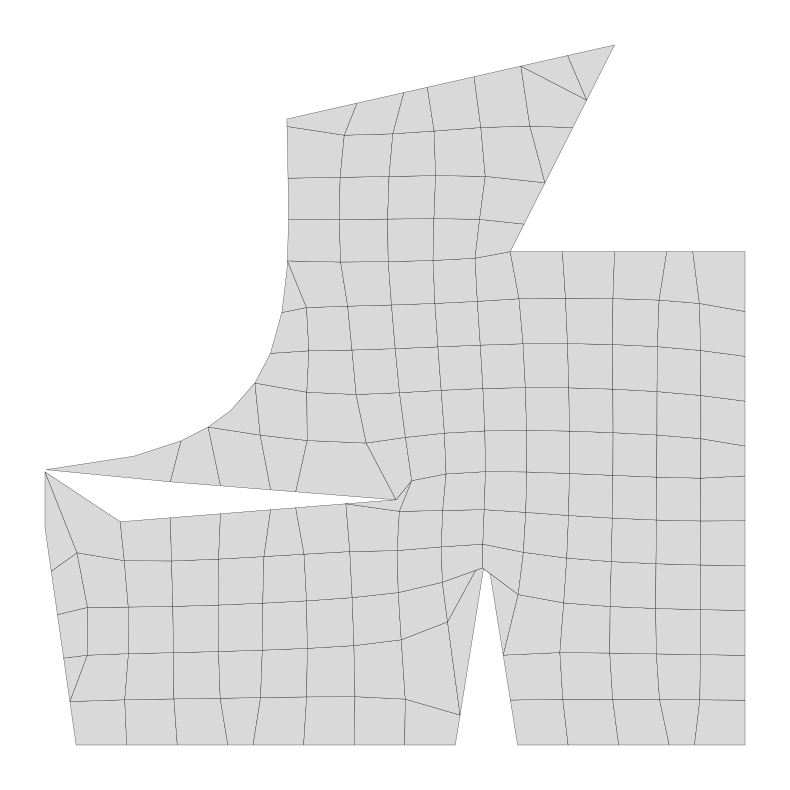

In [70]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve
import scipy
quad_E, _, _ = quad_edges(quad_F)
num_edges = quad_E.shape[0]
bx = np.zeros(num_edges)
by = np.zeros(num_edges)
A_elem, A_ind_i, A_ind_j = [], [], []
for i, edge in enumerate(quad_E):
    v1, v2 = edge
    target_diff = quad_V[v2] - quad_V[v1]
    bx[i] = target_diff[0]
    by[i] = target_diff[1]
    A_elem.append(1)
    A_ind_i.append(i)
    A_ind_j.append(v2)
    A_elem.append(-1)
    A_ind_i.append(i)
    A_ind_j.append(v1)
    
A = csr_matrix((A_elem, (A_ind_i, A_ind_j)), shape=(num_edges, quad_V.shape[0]))

C_elem, C_ind_i, C_ind_j = [], [], []
dx = np.zeros(len(constraints))
dy = np.zeros(len(constraints))
for i, constraint in enumerate(constraints):
    idx, target_v = constraint
    C_elem.append(1)
    C_ind_i.append(i)
    C_ind_j.append(idx)
    dx[i] = target_v[0]
    dy[i] = target_v[1]
C = csr_matrix((C_elem, (C_ind_i, C_ind_j)), shape=(len(constraints), quad_V.shape[0]))
L = scipy.sparse.bmat([[A.T @ A, -C.T], [C, None]])
Bx = np.concatenate([A.T @ bx, dx])
By = np.concatenate([A.T @ by, dy])
# Solve the linear least squares problem
# xs = spsolve(A.T @ A, A.T @ bx)
# ys = spsolve(A.T @ A, A.T @ by)
xs = spsolve(L, Bx)
ys = spsolve(L, By)
deformed_quad_V = np.stack([xs, ys], -1)
fig, ax = plt.subplots(figsize=(10, 10))
ax, _ = plot_quad_mesh(deformed_quad_V, quad_F,  ax=ax)
plt.show()

In [59]:
# V: (n,2) triangulated vertices of your polygon (after seams); F: (m,3) triangles
# bnd: ordered boundary vertex indices along the outer boundary
def tutte_embedding(V, F, bnd):
    # 1) map boundary to square perimeter by arclength
    P = V[bnd]
    L = np.r_[0, np.cumsum(np.linalg.norm(np.diff(np.r_[P, P[:1]], axis=0), axis=1))]
    t = (L[:-1] / L[-1]) * 4.0  # wrap around 4 edges

    def on_square(t):
        k = np.floor(t).astype(int); s = t - k
        out = np.zeros((t.size,2))
        out[k==0] = np.c_[s[k==0], np.zeros(len(s[k==0]))]
        out[k==1] = np.c_[np.ones(len(s[k==1])), s[k==1]]
        out[k==2] = np.c_[1 - s[k==2], np.ones(len(s[k==2]))]
        out[k>=3] = np.c_[np.zeros(len(s[k==3])), 1 - s[k>=3]]
        return out

    bc = on_square(t)

    # 2) harmonic (Tutte/mean-value) parameterization
    #    Use mean value weights for positivity/bijectivity
    U = igl.harmonic(V, F, bnd.astype(np.int32), bc, 1)  # U is (n,2) in the square
    return U


In [ ]:
deformed_vertices = tutte_embedding(V, np.array(right_ftorso.panel_faces), bnd_ids)


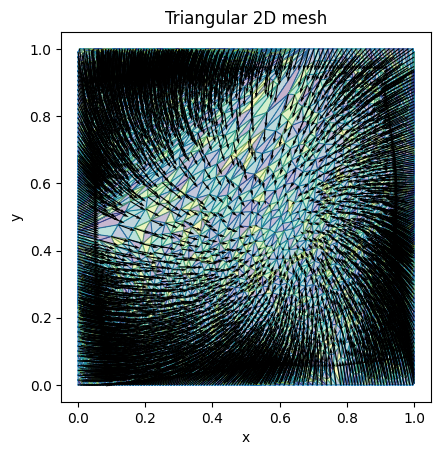

In [ ]:
# bnd_ids = igl.boundary_loop(np.array(right_ftorso.panel_faces))
# V = np.array(right_ftorso.panel_vertices)
# m, M = V.min(0), V.max(0)
# V = (V - m) / (M - m)
# deformed_vertices = tutte_embedding(V, np.array(right_ftorso.panel_faces), bnd_ids)
# fig, ax = plot_tri_mesh(deformed_vertices, np.array(right_ftorso.panel_faces), V - deformed_vertices, 0.1)
# plt.show()

In [1]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 

In [12]:
q = torch.randn([5, 16, 1000, 256]).float().cuda()
k = torch.randn([5, 16, 1000, 256]).float().cuda()
v = torch.randn([5, 16, 1000, 256]).float().cuda()
mask = torch.rand([5, 16, 1000, 1000]).float().cuda()
mask = mask > 0.5

In [1]:
from glob import glob 
import numpy as np 
import os 
import matplotlib.pyplot as plt
data_folder = "/orion/u/w4756677/garment/gcdv2/garment_particles_normal_bnd_fixed"
folders = glob(os.path.join(data_folder, "rand_*"))

In [13]:
from tqdm import tqdm
n_points = []
front_mins = []
front_maxs = []
back_mins = []
back_maxs = []
mins = np.array([-100,  -20])
maxs = np.array([100, 160])
keep_folders = []
for folder in tqdm(folders):
    pattern_name = os.path.basename(folder)
    stat_file = os.path.join(folder, "stats.txt")
    if not os.path.exists(stat_file):
        continue
    stat = np.loadtxt(stat_file)
    n = int(stat[0])
    n_points.append(n)
    front_min = stat[1:6]
    front_max = stat[6:11]
    back_min = stat[11:16]
    back_max = stat[16:21]
    if np.all(front_min[:2] >= mins) and np.all(back_min[:2] >= mins) \
        and np.all(front_max[:2] <= maxs) and np.all(back_max[:2] <= maxs) \
        and n < 8192:
            keep_folders.append(folder)

100%|██████████| 114057/114057 [01:00<00:00, 1896.66it/s]


In [ ]:
import random
with open("/orion/u/w4756677/garment/InteractGarment/src/assets/garment_particle_v2_filtered.txt", "r") as f:
    folders = f.readlines()
train_ratio = 0.9
test_ratio = 0.1 
n_train = int(len(folders) * train_ratio)
random.shuffle(folders)
train_folders = folders[:n_train]
test_folders = folders[n_train:]
print(len(train_folders), len(test_folders))
with open("/orion/u/w4756677/garment/InteractGarment/src/assets/garment_particle_v2_train.txt", "w") as f:
    for folder in train_folders:
        f.write(folder)
        
with open("/orion/u/w4756677/garment/InteractGarment/src/assets/garment_particle_v2_test.txt", "w") as f:
    for folder in test_folders:
        f.write(folder)


77251 8584


[[-101.37260442  -16.4551064   -58.01772842    2.8991146    -9.58330644]]
[[-103.48554639  -20.94577092  -58.09465395    1.34892378  -26.56396361]]
[[107.53252893 162.65971217  58.20777721 148.07092056  24.01613601]]
[[110.00451243 186.84162633  58.2844101  172.33147888  13.15019259]]


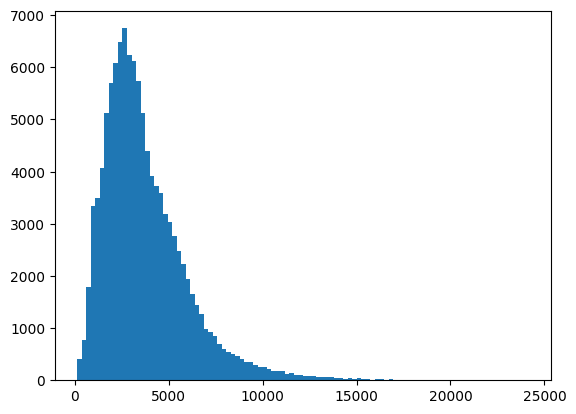

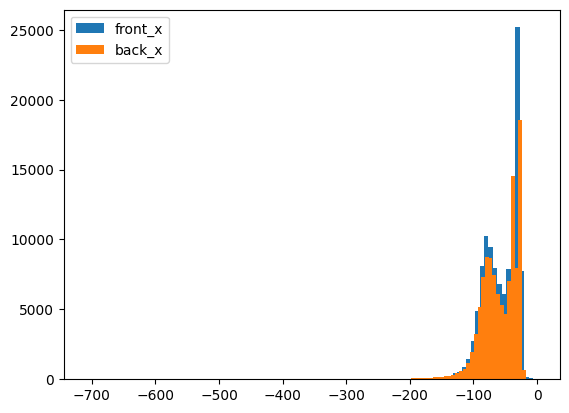

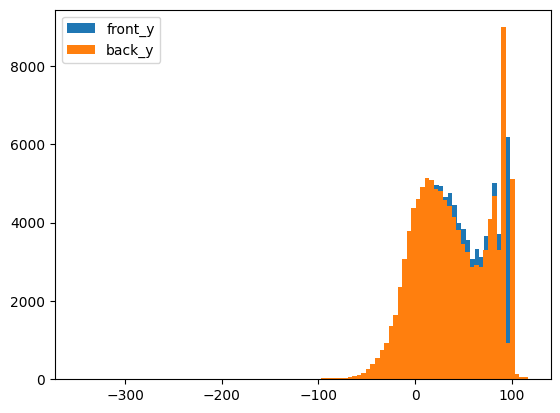

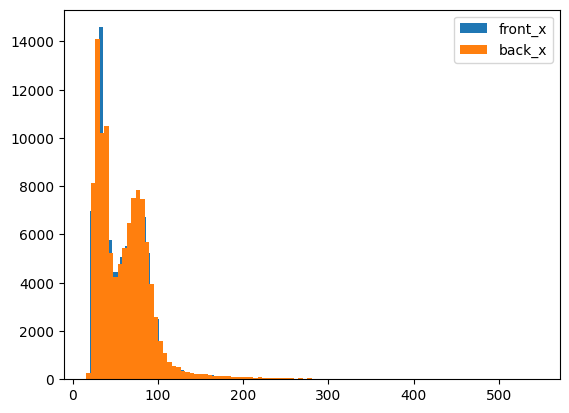

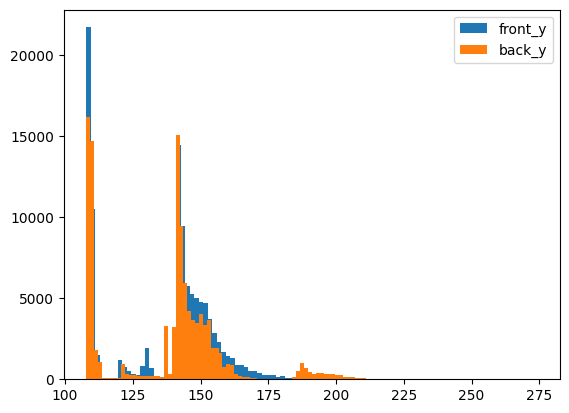

In [ ]:
# n_points = np.array(n_points)
# front_mins = np.stack(front_mins)
# front_maxs = np.stack(front_maxs)
# back_mins = np.stack(back_mins)
# back_maxs = np.stack(back_maxs)
print(np.percentile(front_mins, q=[5], axis=0))
print(np.percentile(back_mins, q=[5], axis=0))
print(np.percentile(front_maxs, q=[95], axis=0))
print(np.percentile(back_maxs, q=[95], axis=0))
plt.hist(n_points, bins=100)
plt.show()
plt.close()
plt.hist(front_mins[:,0], bins=100, label="front_x")
plt.hist(back_mins[:,0], bins=100, label="back_x")
plt.legend()
plt.show()
plt.close()
plt.hist(front_mins[:,1], bins=100, label="front_y")
plt.hist(back_mins[:,1], bins=100, label="back_y")
plt.legend()
plt.show()
plt.close()
plt.hist(front_maxs[:,0], bins=100, label="front_x")
plt.hist(back_maxs[:,0], bins=100, label="back_x")
plt.legend()
plt.show()
plt.close()
plt.hist(front_maxs[:,1], bins=100, label="front_y")
plt.hist(back_maxs[:,1], bins=100, label="back_y")
plt.legend()
plt.show()
plt.close()